# Loading in the data

In [3]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc,make_patient_correlation_matrix
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import torch
import torch.nn.utils.parametrize as parametrize
import geoopt
import os

In [8]:
directory_path = Path('/Users/owenw/Code/School/data_science_projects')

In [9]:
data_root = Path("/Users/owenw/Code/School/data_science_projects/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz,notch_size=.05,minus_mean=True)
print('Data cleaned')

[WindowsPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), WindowsPath('../SuperEeg-M467-p

In [10]:
patient_corr_mat = make_patient_correlation_matrix(xyz_clean,cleaned,mapping_clean)
print('Got Correlation Matrices, done!')

Got Correlation Matrices, done!


# Single patient correlation matrix:

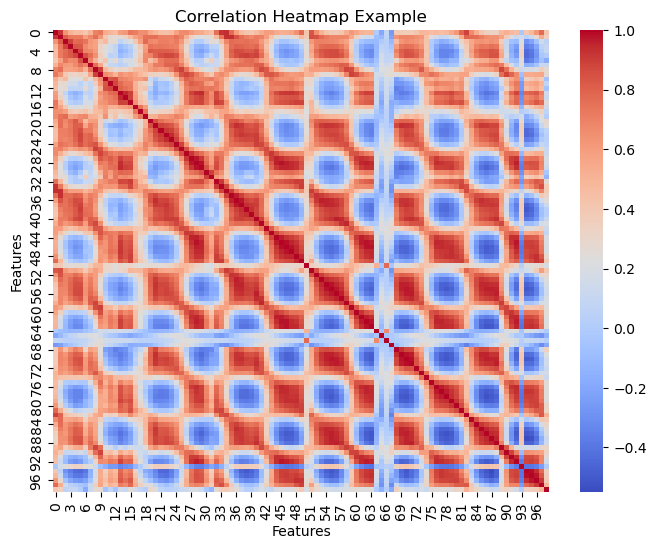

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(patient_corr_mat[8], cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [14]:
from noad_production_funcs import create_u
U_det, loss = create_u(k=30,r=200,lamb=0,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean)

Optimizing U


100%|██████████| 1000/1000 [00:10<00:00, 97.41it/s]


<Axes: >

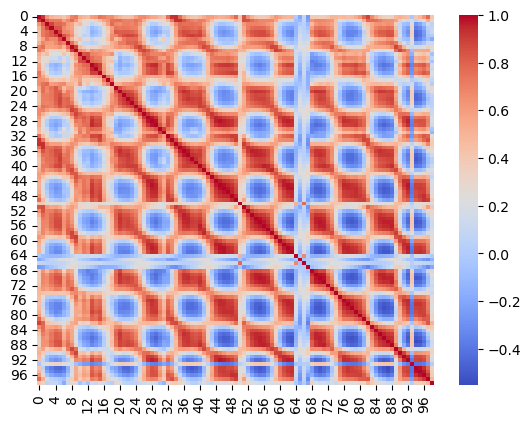

In [38]:
# isolating the brain electrodes for patient 8, to see how well the correlation matrix captures the brain electrode correlations
starting_index_brain = 0
for i in range(0,7):
    starting_index_brain += patient_corr_mat[i].shape[0]
xyz_brain_8 = xyz_clean[starting_index_brain:starting_index_brain+patient_corr_mat[8].shape[0] ,:]



sns.heatmap(patient_corr_mat[8], cmap='coolwarm') 

In [60]:
print(patient_corr_mat[8].__iter__())

<generator object RangeIndex.__iter__ at 0x000001232CC48280>


C:\Users\owenw\AppData\Local\Temp\ipykernel_9244\2632308484.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  dist_and_corr.iloc[i,j] = patient_corr_mat[8].iloc[i,j] / np.sum(np.sqrt((location_row - location_col) ** 2))


<Axes: >

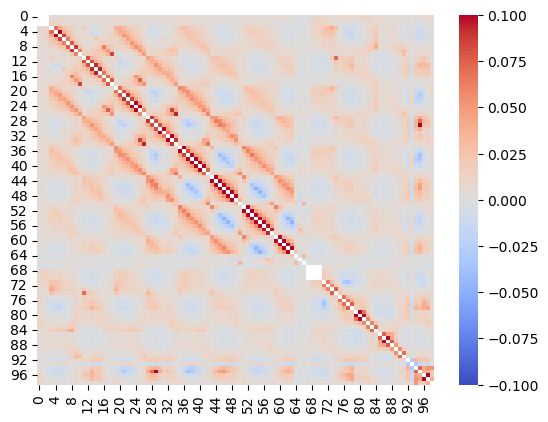

In [ ]:
dist_and_corr = patient_corr_mat[8].copy()
dist_matrix = np.zeros_like(patient_corr_mat[8])

len_dataframe = patient_corr_mat[8].shape[0]
for i, location_row in enumerate(xyz_brain_8):
    for j, location_col in enumerate(xyz_brain_8):
        dist_and_corr.iloc[i,j] = patient_corr_mat[8].iloc[i,j] / np.sum(np.sqrt((location_row - location_col) ** 2))
        dist_matrix[i,j] = np.sum(np.sqrt((location_row - location_col) ** 2))
sns.heatmap(dist_and_corr, cmap='coolwarm') 


<Axes: >

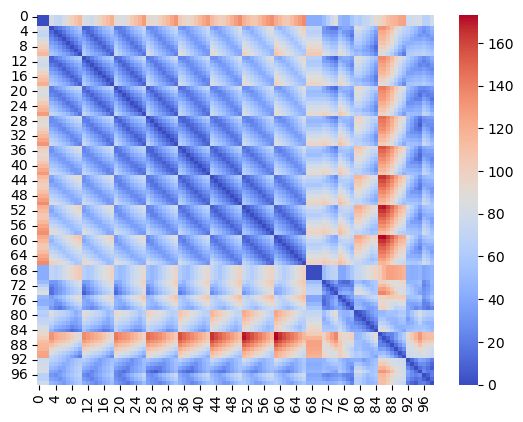

In [72]:
sns.heatmap(dist_matrix, cmap='coolwarm')

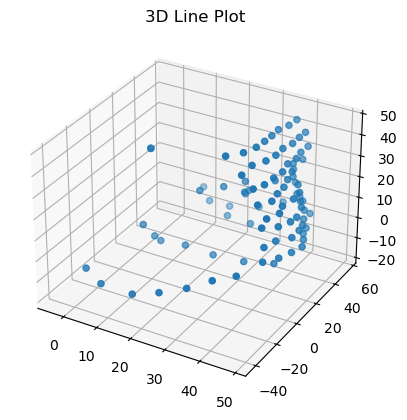

In [43]:
fig = plt.figure()
ax = plt.axes(projection='3d' )

z = xyz_brain_8[:,2]
x = xyz_brain_8[:,0]
y = xyz_brain_8[:,1]  

ax.scatter3D(x, y, z)
ax.set_title('3D Line Plot')
plt.show()

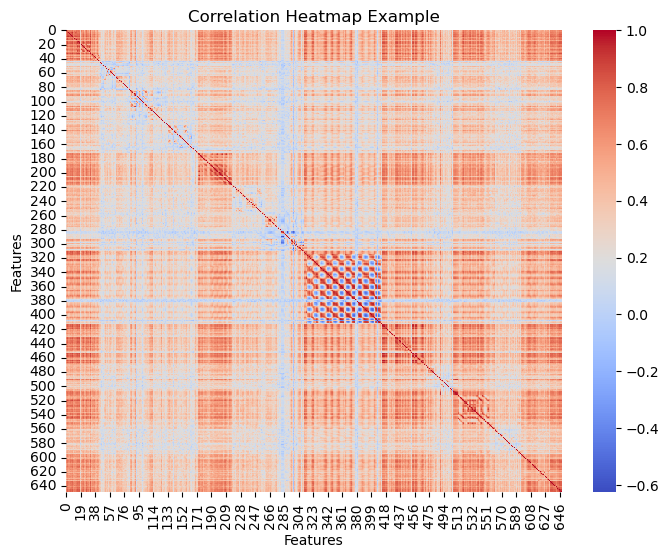

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [ ]:
plt.plot(loss)

In [ ]:
np.diag(U_det@U_det.T)

In [ ]:
def object_func(C,U,L,lamb,patient_node_num):
    sum = torch.zeros(1,requires_grad=True) 
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes] #all columns of rows iter+num of nodes + 1 
        #print(len(u[:,0]))


        ut = torch.empty((100,len(u)))
        iter = 0
        for row in u:
            ut[:,iter] = row
        ######## Compute u@u.T
        print("ut.shape")
        print(ut.shape)
        print(ut)
        #TODO: 
        #TODO: 
        #TODO: Investage whether you can copy things around and get around the constrain anonying stuff
        #TODO: 
        #TODO: 

        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 #+lamb*torch.trace(U.T@L@U)
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(U.T@L@U)
    return sum


def create_u(k,r,lamb,patient_corr_mat,xyz_clean,object_func):
    ############## Make Graph ##############
    num_nodes = xyz_clean.shape[0] #649
    neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
    indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node
    # turn indices lists into pairwiase combos
    all_edges = []
    iter = 0
    for indexs in indicesofneigh:
        for num in indexs:
            all_edges.append((iter,num))
        iter += 1
    G = nx.Graph()
    nodes = np.arange(num_nodes)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_edges)
    ############## Preparing function inputs ##############
    Glaplacian = nx.linalg.laplacian_matrix(G).toarray()
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=False)
    #r = 200
    #lamb = 1
    patient_node_num = []
    C = []
    for corr in patient_corr_mat:
        C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])
    ############## Preparing U and its manifold ##############
    rng = np.random.default_rng()
    sphere = geoopt.manifolds.Sphere()
    U = []
    for i in range(num_nodes): #for each row in the U matrix
        U_intial = rng.uniform(1,2,(1,r)) #random values to start with
        U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U row is normalized
        U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
        U.append(geoopt.ManifoldParameter(U_tensor,manifold=sphere))

    ############## Training U ##############
    optimizer = geoopt.optim.RiemannianAdam(U, lr=0.01)
    loss_list = []
    grads = []
    print("Optimizing U")
    for step in tqdm(range(1000)):
        optimizer.zero_grad()
        z = object_func(C,U,L,lamb,patient_node_num) #this is our loss function
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()
    return U.detach()

In [ ]:
U_det = create_u(k=10,r=100,lamb=1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_clean,object_func=object_func)

In [ ]:
print("Norm of a Column:")
print(torch.linalg.norm(U_det[1,:]))
print("Norm of a Row:")
print(torch.linalg.norm(U_det[1]))

In [ ]:
r=100
rng = np.random.default_rng()
U_intial = rng.uniform(1,2,(2,r)) #random values to start with
U_intial = U_intial/np.linalg.norm(U_intial,axis=1,keepdims=True) #ensuring intial U is normalized
U_tensor = torch.tensor(U_intial,dtype=torch.float32) 
#print(U_tensor)
U = torch.empty((2,r))    
with torch.no_grad():
    U[0] = geoopt.ManifoldParameter(U_tensor[0],manifold=geoopt.Sphere())
    U[1] = geoopt.ManifoldParameter(U_tensor[1],manifold=geoopt.Sphere())
U.requires_grad = True
U = U + torch.ones((2,r))    
#print(U.grad_fn)


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()